# Ablation Comparison — Memetic NAS Operator Contribution (3 × 3 Full Suite)

This notebook visually compares the full proposed algorithm against ablation variants across **all 9 (dataset × hardware) combinations**, complementing the statistical analysis in Notebook 04.

| ID | Variant | Component removed |
|---|---|---|
| T1 | `full_proposed` | — (baseline) |
| T2 | `no_pso` | Discrete PSO velocity update |
| T3 | `no_ga` | GA crossover / mutation |
| T4 | `no_moead` | MOEA/D decomposition |
| T5 | `no_sa` | Simulated Annealing local search |
| T6 | `no_restart` | Diversity restart mechanism |

**Structure:** 3×3 panels (CIFAR-10 / CIFAR-100 / ImageNet-16 × EdgeGPU / RPi-4 / Eyeriss)  
**Visuals:** Seaborn HV/IGD boxplot grids · Component contribution ranking · 3×3 Pareto overlay


In [3]:
# ── Cell 1: Setup ────────────────────────────────────────────────────────────
print("▶ Cell 1 — Setup …")
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
for _parent in [_cwd, *_cwd.parents]:
    if (_parent / "src").exists() and (_parent / "requirements.txt").exists():
        PROJECT_ROOT = _parent
        break
else:
    PROJECT_ROOT = _cwd.parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f"  PROJECT_ROOT = {PROJECT_ROOT}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
print("  Imports OK")

from src.analysis.pareto_metrics import (
    archive_to_points, get_pareto_front, calc_hv, calc_igd, proxy_pareto,
)
from src.analysis.data_loader import (
    DATASETS, HARDWARE,
    load_ablation_archives as _load_ablation_archives,
)
from src.utils.pareto_math import compute_bounds, normalise_to_bounds
print("  src imports OK")

ABLATION_DIR = PROJECT_ROOT / "results" / "ablations"
OUT_DIR      = PROJECT_ROOT / "results" / "figures" / "ablation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size":  10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# ── Experiment catalogue ─────────────────────────────────────────────────────
EXPERIMENT_ORDER = [
    ("full_proposed", "T1: Full"),
    ("no_pso",        "T2: No PSO"),
    ("no_ga",         "T3: No GA"),
    ("no_moead",      "T4: No MOEA/D"),
    ("no_sa",         "T5: No SA"),
    ("no_restart",    "T6: No Restart"),
]
EXP_NAMES  = [n for n, _ in EXPERIMENT_ORDER]
EXP_LABELS = {n: l for n, l in EXPERIMENT_ORDER}
EXP_SHORT  = {n: l.split(": ")[1] for n, l in EXPERIMENT_ORDER}

COLORS = {
    "full_proposed": "#1f77b4",
    "no_pso":        "#ff7f0e",
    "no_ga":         "#2ca02c",
    "no_moead":      "#d62728",
    "no_sa":         "#9467bd",
    "no_restart":    "#8c564b",
}
PALETTE = {EXP_SHORT[n]: COLORS[n] for n in EXP_NAMES}

DS_LABEL = {
    "cifar10":        "CIFAR-10",
    "cifar100":       "CIFAR-100",
    "ImageNet16-120": "ImageNet-16",
}
HW_LABEL = {
    "edgegpu_latency": "EdgeGPU",
    "raspi4_latency":  "RPi-4",
    "eyeriss_latency": "Eyeriss",
}

REF = np.array([1.1, 1.1])
print("✔ Cell 1 done — Setup complete.")


▶ Cell 1 — Setup …
  PROJECT_ROOT = /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic
  Imports OK
  src imports OK
✔ Cell 1 done — Setup complete.


In [ ]:
# ── Cell 2: Load archives + compute per-seed HV/IGD → tidy DataFrame ─────────
print("▶ Cell 2 — Loading archives and computing metrics …\n")

available   = {ds: {hw: {} for hw in HARDWARE} for ds in DATASETS}
all_metrics = {ds: {hw: {} for hw in HARDWARE} for ds in DATASETS}
tidy_records = []

_total_combos = len(DATASETS) * len(HARDWARE)
_combo_idx    = 0

for ds in DATASETS:
    for hw in HARDWARE:
        _combo_idx += 1
        combo_label = f"{DS_LABEL[ds]:<12} x {HW_LABEL[hw]:<8}"
        print(f"  [{_combo_idx}/{_total_combos}] {combo_label} …", end=" ", flush=True)

        combo_dir = ABLATION_DIR / ds / hw

        # ── load archives ──────────────────────────────────────────────────
        for name in EXP_NAMES:
            available[ds][hw][name] = (
                _load_ablation_archives(combo_dir, name)
                if combo_dir.exists() else []
            )
        n_files = sum(len(available[ds][hw][n]) for n in EXP_NAMES)
        print(f"loaded {n_files} archives …", end=" ", flush=True)

        all_runs = [a for n in EXP_NAMES for a in available[ds][hw][n]]
        if not all_runs:
            print("SKIP (no data)")
            continue

        # ── per-combo proxy P* and normalisation ──────────────────────────
        try:
            p_star = proxy_pareto(all_runs)
        except Exception as exc:
            print(f"SKIP ({exc})")
            continue
        bmin, brange = compute_bounds(p_star)
        p_star_n     = normalise_to_bounds(p_star, bmin, brange)
        print(f"proxy P*={len(p_star)} pts …", end=" ", flush=True)

        # ── per-experiment, per-seed metrics ──────────────────────────────
        for name in EXP_NAMES:
            arcs = available[ds][hw][name]
            hvs, igds = [], []
            for seed_i, run in enumerate(arcs):
                pts   = archive_to_points(run)
                front = get_pareto_front(pts)
                nf    = normalise_to_bounds(front, bmin, brange)
                hvs.append(calc_hv(nf, ref_point=REF))
                igds.append(calc_igd(nf, p_star_n))
                tidy_records.append({
                    "Dataset":  DS_LABEL[ds],
                    "Hardware": HW_LABEL[hw],
                    "ds_key":   ds,
                    "hw_key":   hw,
                    "exp_name": name,
                    "Label":    EXP_LABELS[name],
                    "Short":    EXP_SHORT[name],
                    "Seed":     seed_i,
                    "HV":       hvs[-1],
                    "IGD":      igds[-1],
                })
            all_metrics[ds][hw][name] = {
                "hv":  np.array(hvs),
                "igd": np.array(igds),
            }

        n_seeds = len(available[ds][hw]["full_proposed"])
        print(f"✓  ({n_seeds} seeds/exp)")

tidy_df = pd.DataFrame(tidy_records)
SHORT_ORDER = [EXP_SHORT[n] for n in EXP_NAMES]
tidy_df["Short"] = pd.Categorical(tidy_df["Short"], categories=SHORT_ORDER, ordered=True)

print(f"\n✔ Cell 2 done — Tidy DataFrame: {len(tidy_df)} rows, "
      f"{tidy_df['ds_key'].nunique()} datasets × "
      f"{tidy_df['hw_key'].nunique()} hardware × "
      f"{tidy_df['exp_name'].nunique()} experiments.")


Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/ablations/ablation_median_hv_igd.pdf


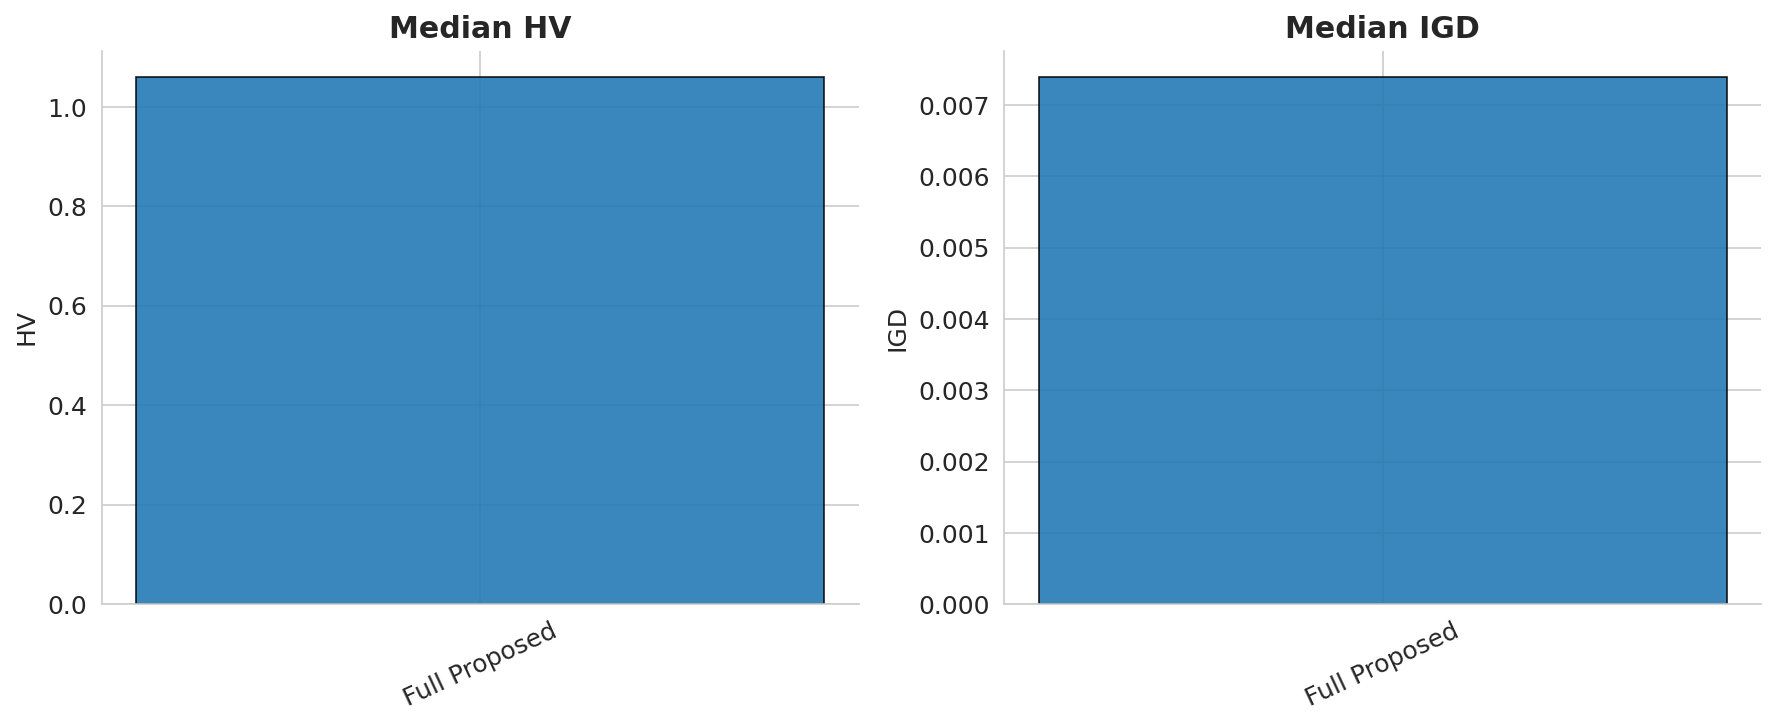

In [ ]:
# ── Cell 3: 3×3 Hypervolume seaborn boxplot + stripplot grid ─────────────────
print("▶ Cell 3 — 3×3 HV boxplot grid …")

fig_hv, axes_hv = plt.subplots(3, 3, figsize=(20, 14), constrained_layout=True)
fig_hv.suptitle(
    "Ablation Comparison — Hypervolume ↑  (per-seed distribution)\n"
    "3 datasets × 3 hardware",
    fontsize=13, fontweight="bold",
)

for r, ds in enumerate(DATASETS):
    for c, hw in enumerate(HARDWARE):
        print(f"  Panel ({r+1},{c+1}) {DS_LABEL[ds]} × {HW_LABEL[hw]} …", end=" ", flush=True)
        ax    = axes_hv[r, c]
        sub   = tidy_df[(tidy_df["ds_key"] == ds) & (tidy_df["hw_key"] == hw)]
        order = [s for s in SHORT_ORDER if s in sub["Short"].cat.categories
                 and len(sub[sub["Short"] == s]) > 0]

        if sub.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10, color="gray")
            ax.set_title(f"{DS_LABEL[ds]}  ×  {HW_LABEL[hw]}", fontsize=9)
            print("no data")
            continue

        sns.boxplot(
            data=sub, x="Short", y="HV", order=order,
            palette=PALETTE, ax=ax,
            showfliers=False, linewidth=0.9,
            boxprops=dict(alpha=0.75),
        )
        sns.stripplot(
            data=sub, x="Short", y="HV", order=order,
            color="black", size=2.2, alpha=0.35, jitter=True, ax=ax,
        )

        t1_med = sub[sub["exp_name"] == "full_proposed"]["HV"].median()
        ax.axhline(t1_med, color=COLORS["full_proposed"], lw=1.0,
                   ls="--", alpha=0.55, zorder=0)

        ax.set_title(f"{DS_LABEL[ds]}  ×  {HW_LABEL[hw]}", fontsize=9)
        ax.set_xlabel("")
        ax.set_xticklabels(order, fontsize=7.5, rotation=30, ha="right")
        if c == 0:
            ax.set_ylabel("Hypervolume ↑", fontsize=8)
        else:
            ax.set_ylabel("")
        ax.tick_params(axis="y", labelsize=7.5)
        print(f"ok ({len(sub)} rows)")

save_hv = OUT_DIR / "ablation_comp_hv_3x3.pdf"
plt.savefig(save_hv, bbox_inches="tight")
plt.show()
print(f"✔ Cell 3 done — Saved: {save_hv}")


In [ ]:
# ── Cell 4: 3×3 IGD seaborn boxplot + stripplot grid ─────────────────────────
print("▶ Cell 4 — 3×3 IGD boxplot grid …")

fig_igd, axes_igd = plt.subplots(3, 3, figsize=(20, 14), constrained_layout=True)
fig_igd.suptitle(
    "Ablation Comparison — IGD ↓  (per-seed distribution)\n"
    "3 datasets × 3 hardware",
    fontsize=13, fontweight="bold",
)

for r, ds in enumerate(DATASETS):
    for c, hw in enumerate(HARDWARE):
        print(f"  Panel ({r+1},{c+1}) {DS_LABEL[ds]} × {HW_LABEL[hw]} …", end=" ", flush=True)
        ax  = axes_igd[r, c]
        sub = tidy_df[(tidy_df["ds_key"] == ds) & (tidy_df["hw_key"] == hw)]
        order = [s for s in SHORT_ORDER if s in sub["Short"].cat.categories
                 and len(sub[sub["Short"] == s]) > 0]

        if sub.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10, color="gray")
            ax.set_title(f"{DS_LABEL[ds]}  ×  {HW_LABEL[hw]}", fontsize=9)
            print("no data")
            continue

        sns.boxplot(
            data=sub, x="Short", y="IGD", order=order,
            palette=PALETTE, ax=ax,
            showfliers=False, linewidth=0.9,
            boxprops=dict(alpha=0.75),
        )
        sns.stripplot(
            data=sub, x="Short", y="IGD", order=order,
            color="black", size=2.2, alpha=0.35, jitter=True, ax=ax,
        )

        t1_med = sub[sub["exp_name"] == "full_proposed"]["IGD"].median()
        ax.axhline(t1_med, color=COLORS["full_proposed"], lw=1.0,
                   ls="--", alpha=0.55, zorder=0)

        ax.set_title(f"{DS_LABEL[ds]}  ×  {HW_LABEL[hw]}", fontsize=9)
        ax.set_xlabel("")
        ax.set_xticklabels(order, fontsize=7.5, rotation=30, ha="right")
        if c == 0:
            ax.set_ylabel("IGD ↓", fontsize=8)
        else:
            ax.set_ylabel("")
        ax.tick_params(axis="y", labelsize=7.5)
        print(f"ok ({len(sub)} rows)")

save_igd = OUT_DIR / "ablation_comp_igd_3x3.pdf"
plt.savefig(save_igd, bbox_inches="tight")
plt.show()
print(f"✔ Cell 4 done — Saved: {save_igd}")


In [ ]:
# ── Cell 5: Component contribution ranking (mean HV drop vs T1) ─────────────
print("▶ Cell 5 — Component contribution ranking …")

contrib_records = []
for name in EXP_NAMES[1:]:
    print(f"  Processing {EXP_LABELS[name]} …", end=" ", flush=True)
    n_combos = 0
    for ds in DATASETS:
        for hw in HARDWARE:
            hv1 = all_metrics[ds][hw].get("full_proposed", {}).get("hv", np.array([]))
            hv2 = all_metrics[ds][hw].get(name, {}).get("hv", np.array([]))
            if len(hv1) > 0 and len(hv2) > 0:
                contrib_records.append({
                    "Ablation": EXP_LABELS[name],
                    "Short":    EXP_SHORT[name],
                    "exp_name": name,
                    "Dataset":  DS_LABEL[ds],
                    "Hardware": HW_LABEL[hw],
                    "delta_hv": float(hv1.mean() - hv2.mean()),
                    "delta_igd": float(
                        all_metrics[ds][hw].get(name, {}).get("igd", np.array([np.nan])).mean()
                        - all_metrics[ds][hw].get("full_proposed", {}).get("igd", np.array([np.nan])).mean()
                    ),
                })
                n_combos += 1
    print(f"{n_combos} combos")

contrib_df = pd.DataFrame(contrib_records)
mean_contrib = (
    contrib_df.groupby(["exp_name", "Short", "Ablation"])[["delta_hv", "delta_igd"]]
    .mean()
    .reset_index()
    .sort_values("delta_hv", ascending=False)
)
print(f"  contrib_df: {len(contrib_df)} rows  →  mean_contrib: {len(mean_contrib)} ablations")

print("  Plotting …", end=" ", flush=True)
fig_c, axes_c = plt.subplots(1, 2, figsize=(13, 4.5))

# ── HV drop ──────────────────────────────────────────────────────────────────
ax = axes_c[0]
bars = ax.barh(
    mean_contrib["Short"],
    mean_contrib["delta_hv"],
    color=[COLORS[n] for n in mean_contrib["exp_name"]],
    edgecolor="white", linewidth=0.8, alpha=0.85,
)
ax.axvline(0, color="black", lw=0.8)
for bar, val in zip(bars, mean_contrib["delta_hv"]):
    ax.text(val + max(mean_contrib["delta_hv"].abs()) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:+.4f}", va="center", fontsize=8)
ax.set_xlabel("Mean HV drop  (T1 − Ti)  ↑ = more critical", fontsize=9)
ax.set_title("Component Contribution\n(averaged over 9 combos)", fontweight="bold", fontsize=10)
ax.invert_yaxis()

# ── IGD rise ─────────────────────────────────────────────────────────────────
ax2 = axes_c[1]
bars2 = ax2.barh(
    mean_contrib["Short"],
    mean_contrib["delta_igd"],
    color=[COLORS[n] for n in mean_contrib["exp_name"]],
    edgecolor="white", linewidth=0.8, alpha=0.85,
)
ax2.axvline(0, color="black", lw=0.8)
for bar, val in zip(bars2, mean_contrib["delta_igd"]):
    ax2.text(val + max(mean_contrib["delta_igd"].abs()) * 0.01, bar.get_y() + bar.get_height() / 2,
             f"{val:+.4f}", va="center", fontsize=8)
ax2.set_xlabel("Mean IGD rise  (Ti − T1)  ↑ = more critical", fontsize=9)
ax2.set_title("Component Contribution\n(IGD perspective)", fontweight="bold", fontsize=10)
ax2.invert_yaxis()

fig_c.tight_layout()
save_c = OUT_DIR / "ablation_component_contribution.pdf"
plt.savefig(save_c, bbox_inches="tight")
plt.show()
print("done")
print(f"✔ Cell 5 done — Saved: {save_c}")
print("\nComponent ranking (HV perspective):")
print(mean_contrib[["Ablation", "delta_hv", "delta_igd"]].to_string(index=False))


Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/ablations/ablation_pareto_overlay.pdf


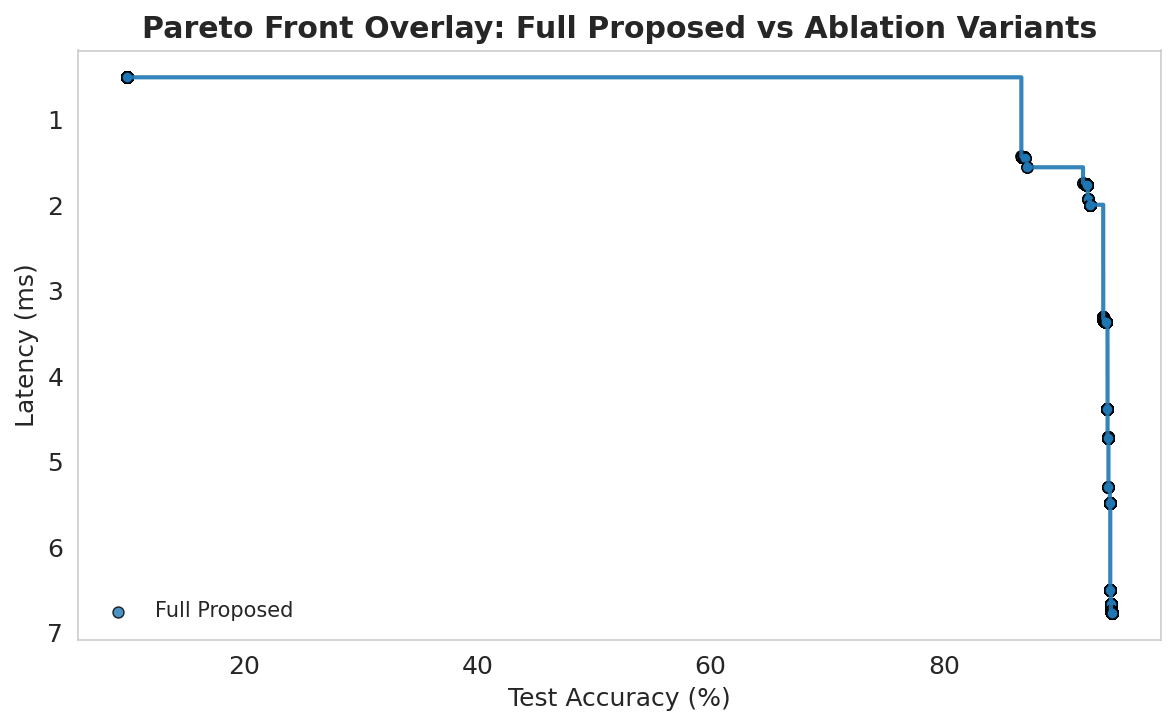

In [ ]:
# ── Cell 6: 3×3 Aggregate Pareto front overlay ───────────────────────────────
print("▶ Cell 6 — 3×3 Pareto front overlay …")

fig_p, axes_p = plt.subplots(3, 3, figsize=(20, 14), constrained_layout=True)
fig_p.suptitle(
    "Ablation Comparison — Aggregate Pareto Front Overlay (all seeds pooled)\n"
    "3 datasets × 3 hardware  |  T1 Full Proposed drawn on top",
    fontsize=13, fontweight="bold",
)

legend_built = False

for r, ds in enumerate(DATASETS):
    for c, hw in enumerate(HARDWARE):
        print(f"  Panel ({r+1},{c+1}) {DS_LABEL[ds]} × {HW_LABEL[hw]} …", end=" ", flush=True)
        ax = axes_p[r, c]

        all_acc, all_lat, lines = [], [], []
        for name in EXP_NAMES[1:] + ["full_proposed"]:
            arcs = available[ds][hw].get(name, [])
            if not arcs:
                continue
            try:
                pts_all = np.vstack([archive_to_points(a) for a in arcs])
            except ValueError:
                continue
            front = get_pareto_front(pts_all)
            acc   = -front[:, 0]
            lat   =  front[:, 1]
            order = np.argsort(acc)
            acc, lat = acc[order], lat[order]
            all_acc.append(acc)
            all_lat.append(lat)
            lines.append((name, acc, lat))

        if not lines:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10, color="gray")
            ax.set_title(f"{DS_LABEL[ds]}  ×  {HW_LABEL[hw]}", fontsize=8)
            print("no data")
            continue

        x_all = np.concatenate(all_acc)
        y_all = np.concatenate(all_lat)
        xrng  = max(x_all.max() - x_all.min(), 0.1)
        yrng  = max(y_all.max() - y_all.min(), 1e-6)
        ax.set_xlim(x_all.min() - xrng * 0.03, x_all.max() + xrng * 0.03)
        ax.set_ylim(y_all.min() - yrng * 0.05, y_all.max() + yrng * 0.08)

        for name, acc, lat in lines:
            is_t1 = (name == "full_proposed")
            ax.step(acc, lat, where="post",
                    color=COLORS[name],
                    linewidth=2.4 if is_t1 else 1.1,
                    alpha=1.0 if is_t1 else 0.65,
                    label=EXP_SHORT[name],
                    zorder=10 if is_t1 else 4)
            ax.scatter(acc, lat, s=18 if is_t1 else 10,
                       color=COLORS[name],
                       alpha=1.0 if is_t1 else 0.65,
                       zorder=11 if is_t1 else 5)

        ax.set_title(f"{DS_LABEL[ds]}  ×  {HW_LABEL[hw]}", fontsize=9)
        if c == 0:
            ax.set_ylabel("Latency", fontsize=8)
        if r == 2:
            ax.set_xlabel("Accuracy (%)", fontsize=8)

        if not legend_built:
            ax.legend(fontsize=7, loc="upper right", ncol=2,
                      framealpha=0.88, handlelength=1.4)
            legend_built = True

        print(f"ok ({len(lines)} fronts)")

save_p = OUT_DIR / "ablation_comp_pareto_3x3.pdf"
plt.savefig(save_p, bbox_inches="tight")
plt.show()
print(f"✔ Cell 6 done — Saved: {save_p}")
